<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/borges/RA1_LAB1/Datos_Laboratorio_N%C2%B01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Experiencia 1: Sistema de alerta temprana ACV en atención primaria

##Librerias Generales a importar y carga de dataset

In [50]:
# Importación, visualización, manipulación de datos
import sys
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
import warnings
from sklearn.impute import KNNImputer


warnings.filterwarnings('ignore') # Mantenemos los logs limpios


In [51]:
!wget https://github.com/Santibareiro27/Inteligencia-Computacional/blob/main/RA1_LAB1/datos_acv.csv

--2026-04-10 14:07:25--  https://github.com/Santibareiro27/Inteligencia-Computacional/blob/main/RA1_LAB1/datos_acv.csv
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘datos_acv.csv.4’

datos_acv.csv.4         [ <=>                ]   2.55M  --.-KB/s    in 0.09s   

2026-04-10 14:07:27 (27.6 MB/s) - ‘datos_acv.csv.4’ saved [2677387]



##1. Análisis Exploratorio de Datos (EDA)

In [52]:
# Lectura del dataset
df_acv = pd.read_csv("/content/datos_acv.csv")
df_acv

,id,genero,edad,hipertension,enfermedad_corazon,casado_alguna_vez,tipo_trabajo,tipo_residencia,nivel_glucosa,imc,estado_fumador,apoplejia
0,9046,hombre,67.0,0,1,1,privado,urbano,228.69,36.6,fumaba,1
1,51676,mujer,61.0,0,0,1,autonomo,rural,202.21,NaN,nunca,1
2,31112,hombre,80.0,0,1,1,privado,rural,105.92,32.5,nunca,1
3,60182,mujer,49.0,0,0,1,privado,urbano,171.23,34.4,fuma,1
4,1665,mujer,79.0,1,0,1,autonomo,rural,174.12,24.0,nunca,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,mujer,80.0,1,0,1,privado,urbano,83.75,NaN,nunca,0
5106,44873,mujer,81.0,0,0,1,autonomo,urbano,125.20,40.0,nunca,0
5107,19723,mujer,35.0,0,0,1,autonomo,rural,82.99,30.6,nunca,0
5108,37544,hombre,51.0,0,0,1,privado,rural,166.29,25.6,fumaba,0


In [53]:
# Lista de features categóricos y binarios
cat_features = ['genero', 'hipertension', 'enfermedad_corazon', 'casado_alguna_vez', 'tipo_trabajo', 'tipo_residencia', 'estado_fumador']

print("Conteo de casos de apoplejía (1) por cada clase de feature:\n")
for col in cat_features:
    if col in df_acv.columns:
        # Agrupamos por el feature y sumamos los casos de apoplejia
        conteo = df_acv[df_acv['apoplejia'] == 1].groupby(col).size().reset_index(name='casos_apoplejia')
        print(f"--- Feature: {col.upper()} ---")
        print(conteo)
        print("\n")

Conteo de casos de apoplejía (1) por cada clase de feature:

--- Feature: GENERO ---
   genero  casos_apoplejia
0  hombre              108
1   mujer              141


--- Feature: HIPERTENSION ---
   hipertension  casos_apoplejia
0             0              183
1             1               66


--- Feature: ENFERMEDAD_CORAZON ---
   enfermedad_corazon  casos_apoplejia
0                   0              202
1                   1               47


--- Feature: CASADO_ALGUNA_VEZ ---
   casado_alguna_vez  casos_apoplejia
0                  0               29
1                  1              220


--- Feature: TIPO_TRABAJO ---
    tipo_trabajo  casos_apoplejia
0       autonomo               65
1      con_niños                2
2  gubernamental               33
3        privado              149


--- Feature: TIPO_RESIDENCIA ---
  tipo_residencia  casos_apoplejia
0           rural              114
1          urbano              135


--- Feature: ESTADO_FUMADOR ---
  estado_fumador  cas

Cantidad de pacientes que sufrieron un ACV: 249
Cantidad de pacientes que NO sufrieron un ACV: 4861
Porcentaje de pacientes con ACV: 4.87%


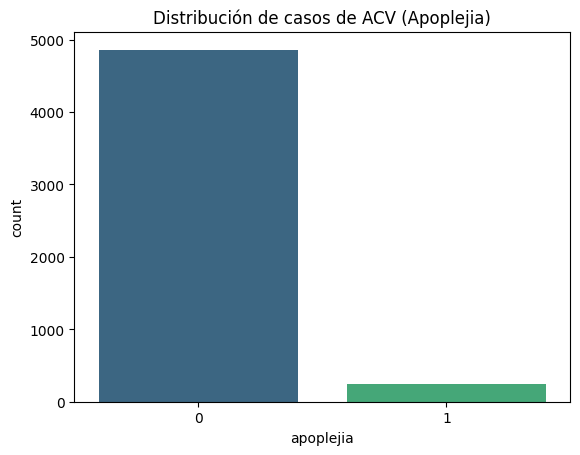

In [54]:
# Conteo de pacientes que sufrieron un ACV (apoplejia = 1)
conteo_acv = df_acv['apoplejia'].value_counts()
porcentaje_acv = (conteo_acv[1] / len(df_acv)) * 100

print(f"Cantidad de pacientes que sufrieron un ACV: {conteo_acv[1]}")
print(f"Cantidad de pacientes que NO sufrieron un ACV: {conteo_acv[0]}")
print(f"Porcentaje de pacientes con ACV: {porcentaje_acv:.2f}%")

# Visualización rápida
sns.countplot(data=df_acv, x='apoplejia', palette='viridis')
plt.title('Distribución de casos de ACV (Apoplejia)')
plt.show()

In [55]:
# Cálculo de valores faltantes y conteo de ACV en nulos
faltantes = df_acv.isnull().sum()
porcentaje = (df_acv.isnull().sum() / len(df_acv) * 100).round(2)

conteo_acv_en_nulos = {}
for col in df_acv.columns:
    nulos_de_columna = df_acv[df_acv[col].isnull()]
    if len(nulos_de_columna) > 0:
        cantidad_con_acv = nulos_de_columna['apoplejia'].sum()
        conteo_acv_en_nulos[col] = cantidad_con_acv
    else:
        conteo_acv_en_nulos[col] = 0

resumen_nulos = pd.DataFrame({
    'Valores Faltantes': faltantes,
    'Porcentaje Faltante (%)': porcentaje,
    'Num. de nulos con apoplejía': pd.Series(conteo_acv_en_nulos)
})

print("Análisis de valores faltantes y su relación con ACV:")
display(resumen_nulos)

Análisis de valores faltantes y su relación con ACV:


,Valores Faltantes,Porcentaje Faltante (%),Num. de nulos con apoplejía
id,0,0.00,0
genero,0,0.00,0
edad,0,0.00,0
hipertension,0,0.00,0
enfermedad_corazon,0,0.00,0
casado_alguna_vez,0,0.00,0
tipo_trabajo,0,0.00,0
tipo_residencia,0,0.00,0
nivel_glucosa,0,0.00,0
imc,201,3.93,40


In [56]:
# Identificar columnas categóricas
cat_features = df_acv.select_dtypes(include=['object']).columns.tolist()
# También incluimos algunas variables que aunque son numéricas actúan como categorías binarias
cat_features.extend(['hipertension', 'enfermedad_corazon', 'casado_alguna_vez'])

print("Conteo de frecuencias para features categóricos:\n")
for col in set(cat_features):
    if col in df_acv.columns:
        print(f"--- {col.upper()} ---")
        print(df_acv[col].value_counts())
        print("\n")

Conteo de frecuencias para features categóricos:

--- TIPO_TRABAJO ---
tipo_trabajo
privado          2925
autonomo          819
con_niños         687
gubernamental     657
nunca_trabajo      22
Name: count, dtype: int64


--- ENFERMEDAD_CORAZON ---
enfermedad_corazon
0    4834
1     276
Name: count, dtype: int64


--- HIPERTENSION ---
hipertension
0    4612
1     498
Name: count, dtype: int64


--- GENERO ---
genero
mujer     2994
hombre    2115
otro         1
Name: count, dtype: int64


--- CASADO_ALGUNA_VEZ ---
casado_alguna_vez
1    3353
0    1757
Name: count, dtype: int64


--- TIPO_RESIDENCIA ---
tipo_residencia
urbano    2596
rural     2514
Name: count, dtype: int64


--- ESTADO_FUMADOR ---
estado_fumador
nunca          1892
desconocido    1544
fumaba          885
fuma            789
Name: count, dtype: int64




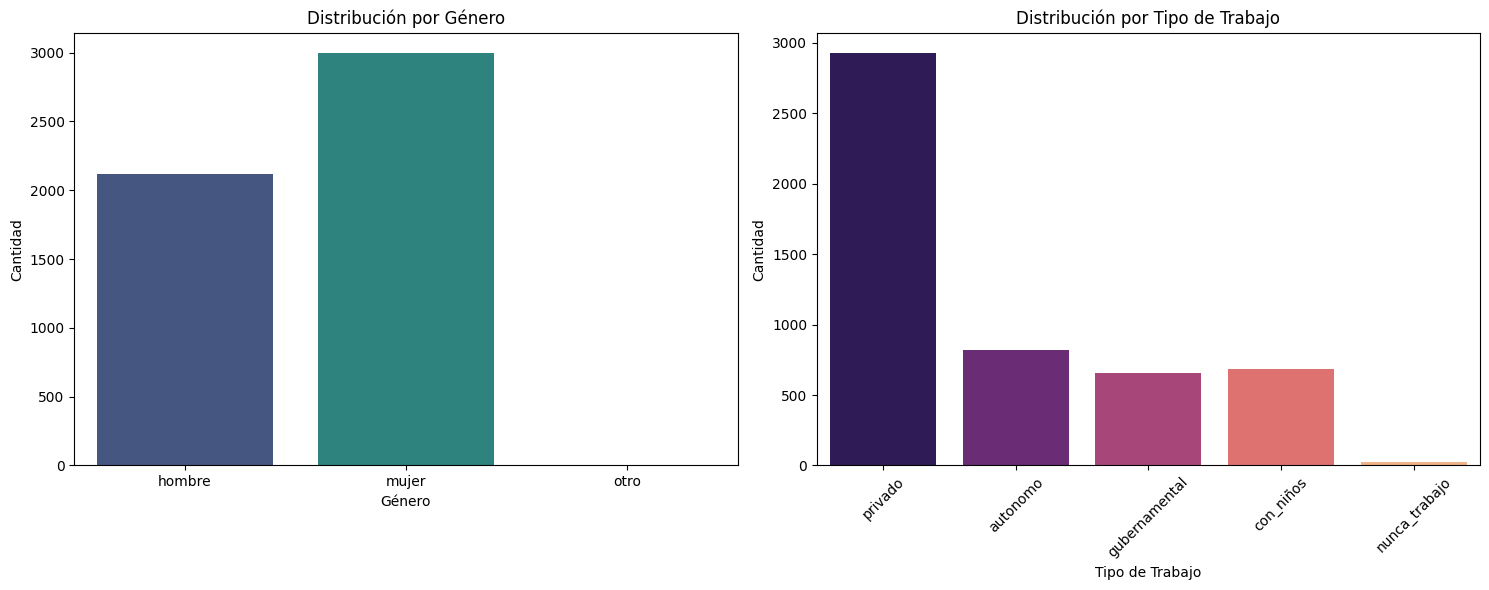

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Configuración de la figura para dos gráficos
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico de barras para Genero - Cambiado df_plot por df_acv
sns.countplot(data=df_acv, x='genero', ax=axes[0], palette='viridis')
axes[0].set_title('Distribución por Género')
axes[0].set_xlabel('Género')
axes[0].set_ylabel('Cantidad')

# Gráfico de barras para Tipo de Trabajo - Cambiado df_plot por df_acv
sns.countplot(data=df_acv, x='tipo_trabajo', ax=axes[1], palette='magma')
axes[1].set_title('Distribución por Tipo de Trabajo')
axes[1].set_xlabel('Tipo de Trabajo')
axes[1].set_ylabel('Cantidad')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [58]:
df_acv = df_acv[df_acv['genero'] != 'otro']
df_acv = df_acv[df_acv['tipo_trabajo'] != 'nunca_trabajo']

print('Registros filtrados.')
print(f'Nuevas dimensiones del dataset: {df_acv.shape}')
print('\nConteo actualizado de genero:')
print(df_acv['genero'].value_counts())
print('\nConteo actualizado de tipo_trabajo:')
print(df_acv['tipo_trabajo'].value_counts())

Registros filtrados.
Nuevas dimensiones del dataset: (5087, 12)

Conteo actualizado de genero:
genero
mujer     2983
hombre    2104
Name: count, dtype: int64

Conteo actualizado de tipo_trabajo:
tipo_trabajo
privado          2924
autonomo          819
con_niños         687
gubernamental     657
Name: count, dtype: int64


In [59]:
# Conteo de edades negativas
edades_negativas = df_acv[df_acv['edad'] < 0]
cantidad_negativas = len(edades_negativas)

print(f'Cantidad de registros con edad negativa: {cantidad_negativas}')
if cantidad_negativas > 0:
    display(edades_negativas)
else:
    print('No se detectaron edades negativas en el dataset.')

Cantidad de registros con edad negativa: 0
No se detectaron edades negativas en el dataset.


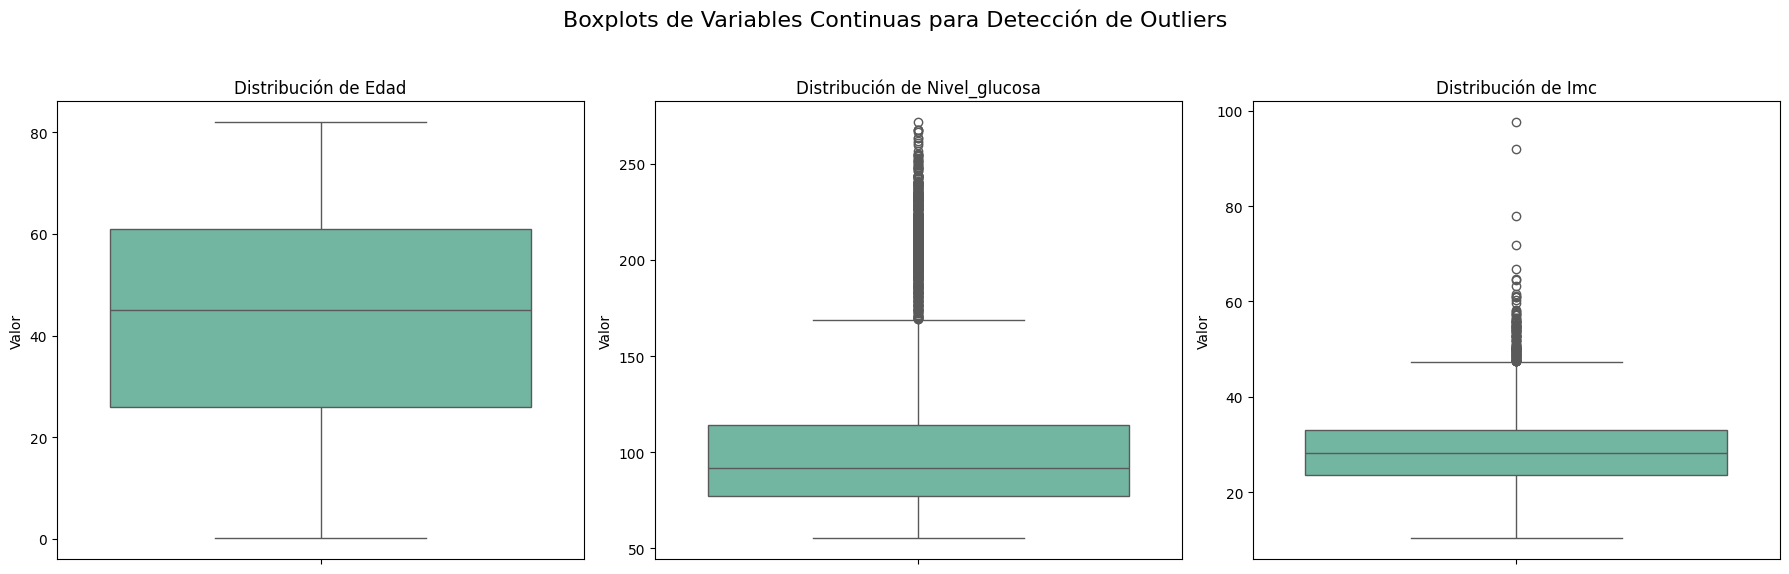

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definir variables continuas
continuas = ['edad', 'nivel_glucosa', 'imc']

# Configuración de la figura
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Boxplots de Variables Continuas para Detección de Outliers', fontsize=16)

for i, col in enumerate(continuas):
    sns.boxplot(data=df_acv, y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribución de {col.capitalize()}')
    axes[i].set_ylabel('Valor')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

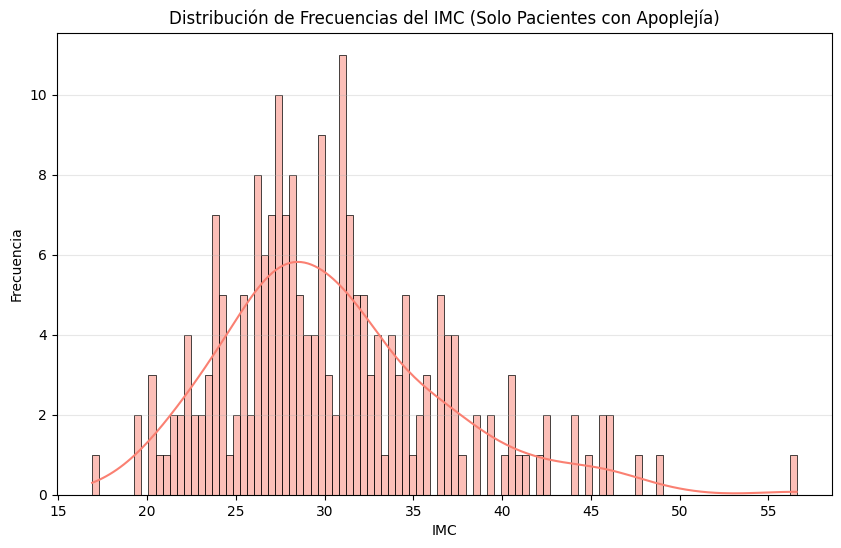


Cantidad de pacientes apopléjicos con IMC >= 60: 0
Porcentaje de outliers (IMC >= 60) en pacientes con ACV: 0.00%


In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the dataframe for positive stroke cases
df_stroke_positive = df_acv[df_acv['apoplejia'] == 1]

# Plot frequency of BMI for stroke patients only
plt.figure(figsize=(10, 6))
sns.histplot(df_stroke_positive['imc'].dropna(), bins=100, kde=True, color='salmon')
plt.title('Distribución de Frecuencias del IMC (Solo Pacientes con Apoplejía)')
plt.xlabel('IMC')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Count and percentage of stroke patients with BMI >= 60
count_high_bmi = len(df_stroke_positive[df_stroke_positive['imc'] >= 60])
total_stroke_patients = len(df_stroke_positive)
percentage_high_bmi = (count_high_bmi / total_stroke_patients) * 100

print(f'\nCantidad de pacientes apopléjicos con IMC >= 60: {count_high_bmi}')
print(f'Porcentaje de outliers (IMC >= 60) en pacientes con ACV: {percentage_high_bmi:.2f}%')

In [62]:
import numpy as np

# Filtrado de valores extremos en IMC (fuera del rango 12-60)
df_acv.loc[(df_acv['imc'] < 12) | (df_acv['imc'] > 60), 'imc'] = np.nan

# Filtrado de valores extremos en glucosa (menor a 40)
df_acv.loc[df_acv['nivel_glucosa'] < 40, 'nivel_glucosa'] = np.nan

# Convertir 'desconocido' en estado_fumador a nulo
df_acv.loc[df_acv['estado_fumador'] == 'desconocido', 'estado_fumador'] = np.nan

# Verificación de nuevos nulos generados
print('Resumen de valores nulos tras la limpieza de extremos y desconocidos:')
print(df_acv[['imc', 'nivel_glucosa', 'estado_fumador']].isnull().sum())

Resumen de valores nulos tras la limpieza de extremos y desconocidos:
imc                217
nivel_glucosa        0
estado_fumador    1536
dtype: int64


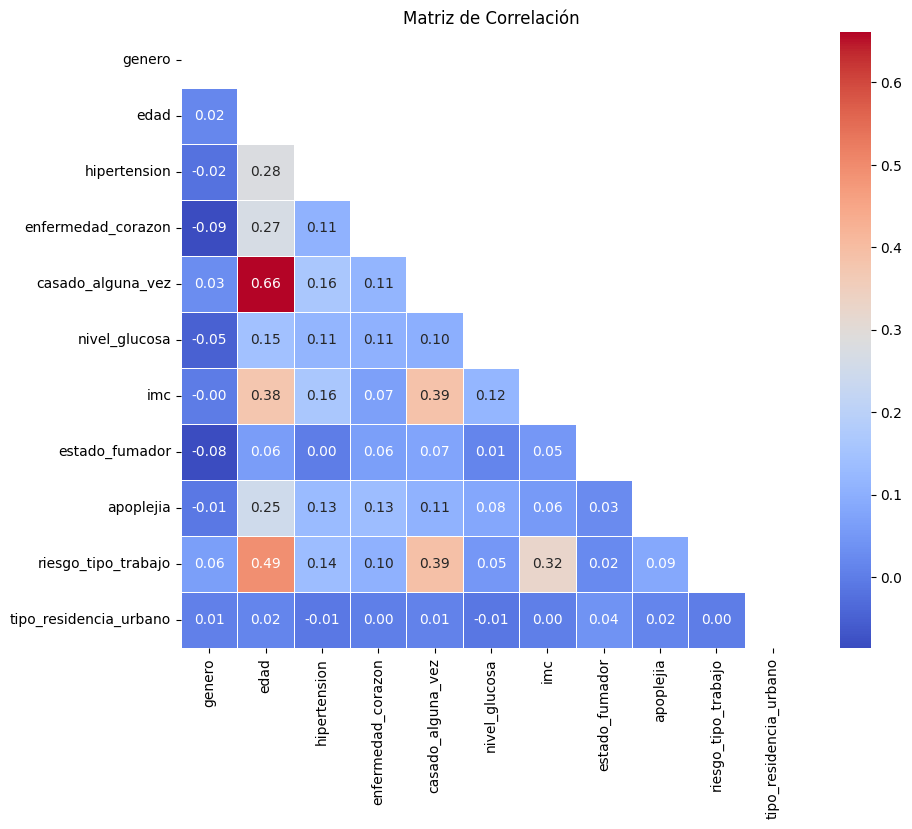

In [64]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Asumiendo que partes de tu df_acv limpio
df_encoded = df_acv.copy()

# 1. Manual Encoding for Gender
df_encoded['genero'] = df_encoded['genero'].map({'hombre': 0, 'mujer': 1})

# 2. Ordinal Encoding for Smoking Status
smoking_map = {'nunca': 1, 'fumaba': 2, 'fuma': 3}
df_encoded['estado_fumador'] = df_encoded['estado_fumador'].map(smoking_map)

# 3. TARGET ENCODING PARA TIPO DE TRABAJO
riesgo_por_trabajo = df_encoded.groupby('tipo_trabajo')['apoplejia'].mean()
df_encoded['riesgo_tipo_trabajo'] = df_encoded['tipo_trabajo'].map(riesgo_por_trabajo)

# 4. One-Hot Encoding SOLO para Residencia
df_encoded = pd.get_dummies(df_encoded, columns=['tipo_residencia'], drop_first=True, dtype=int)

# Borramos la columna de texto original de trabajo (y el ID si está)
columnas_a_borrar = ['tipo_trabajo', 'id']
df_encoded = df_encoded.drop(columns=[col for col in columnas_a_borrar if col in df_encoded.columns])

# 5. Generamos la matriz con Spearman
corr_matrix = df_encoded.corr(method='spearman')

# 6. Crear una máscara para eliminar el espejado (triángulo superior)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Visualización
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()

In [65]:
# Eliminación de columnas específicas
columnas_eliminar = ['casado_alguna_vez', 'tipo_trabajo', 'tipo_residencia']
df_acv = df_acv.drop(columns=[col for col in columnas_eliminar if col in df_acv.columns])

print(f'Columnas eliminadas. Nuevas columnas: {df_acv.columns.tolist()}')

Columnas eliminadas. Nuevas columnas: ['id', 'genero', 'edad', 'hipertension', 'enfermedad_corazon', 'nivel_glucosa', 'imc', 'estado_fumador', 'apoplejia']
